In [1]:
import trimesh
import numpy as np
import torch
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from core import *
import viz as viz

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device ->", device)

cell_cfg = CellConfig(hidden_channels=8, visible_channels=1, alive_threshold=0.05)
perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=False, fire_rate=0.5)
grid_cfg = GridConfig(size=(32, 32, 32))

model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)

device -> cuda


In [3]:
# Donut by Jameson Harman [CC-BY] (https://creativecommons.org/licenses/by/3.0/) 
# via Poly Pizza (https://poly.pizza/m/bsK401uxa3X)
mesh = trimesh.load('../assets/donut/model.obj', force='mesh')
mesh.show()

bounds = mesh.bounds
center = (bounds[0] + bounds[1]) / 2
scale = (bounds[1] - bounds[0]).max()
mesh.vertices = (mesh.vertices - center) / scale * 0.8

pitch = 2.0 / grid_cfg.size[0]
voxels = mesh.voxelized(pitch=pitch).matrix.astype(np.float32)

result = np.zeros((grid_cfg.size[0], grid_cfg.size[0], grid_cfg.size[0]), dtype=np.float32)
slices_src, slices_dst = [], []
for i in range(3):
    if voxels.shape[i] < grid_cfg.size[0]:
        offset = (grid_cfg.size[0] - voxels.shape[i]) // 2
        slices_src.append(slice(0, voxels.shape[i]))
        slices_dst.append(slice(offset, offset + voxels.shape[i]))
    else:
        offset = (voxels.shape[i] - grid_cfg.size[0]) // 2
        slices_src.append(slice(offset, offset + grid_cfg.size[0]))
        slices_dst.append(slice(0, grid_cfg.size[0]))

result[slices_dst[0], slices_dst[1], slices_dst[2]] = voxels[slices_src[0], slices_src[1], slices_src[2]]
target = torch.from_numpy(result).unsqueeze(0).unsqueeze(0).to(device)

print(f"Target voxels: {target.sum().item():.0f}")

Target voxels: 571


In [4]:
print("stability run:")
state = model.seed_center(batch_size=1, device=device)
state += 1e-3 * torch.randn_like(state)
with torch.no_grad():
    for i in range(8):
        state = model(state, steps=1)
        print(f"step {i:02d} mean={state.mean().item():+.6f} std={state.std().item():.6f}")

stability run:
step 00 mean=+0.000003 std=0.001842
step 01 mean=+0.000003 std=0.001844
step 02 mean=+0.000003 std=0.001854
step 03 mean=+0.000002 std=0.001890
step 04 mean=+0.000001 std=0.002028
step 05 mean=-0.000001 std=0.002505
step 06 mean=-0.000005 std=0.003864
step 07 mean=-0.000014 std=0.007040



starting multi-step training
Iter 00001, Loss=0.543518, Mean Alpha=0.0021


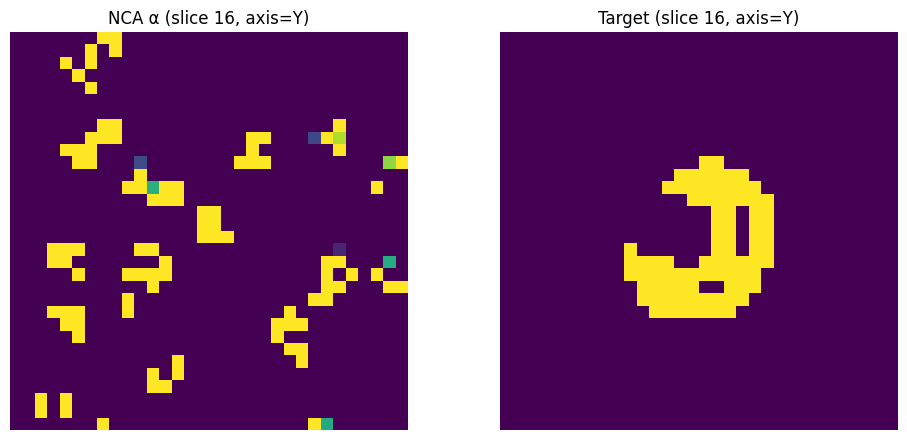

Iter 00200, Loss=0.125799, Mean Alpha=0.0086


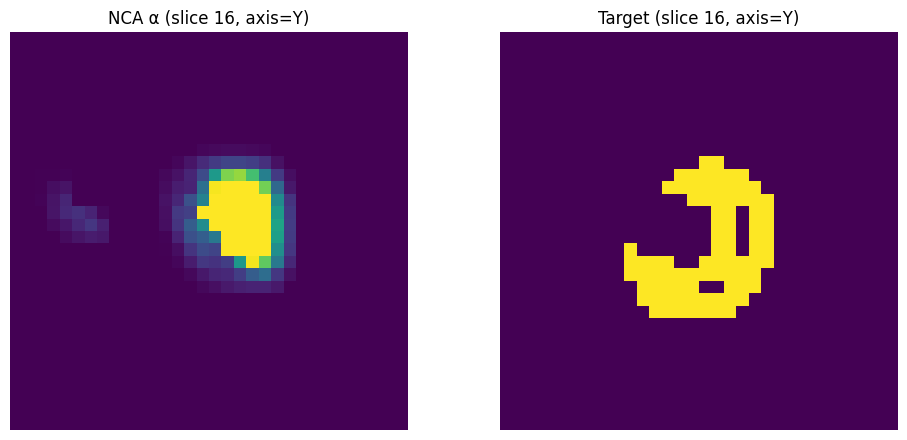

Iter 00400, Loss=0.123217, Mean Alpha=0.0081


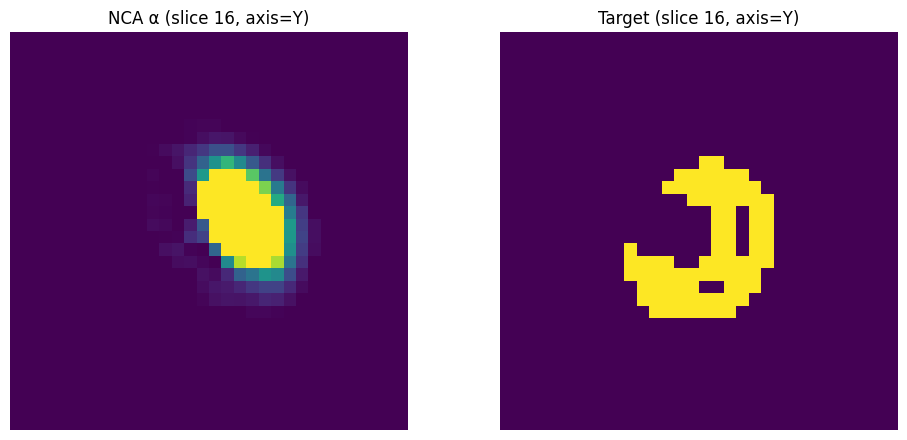

Iter 00600, Loss=0.116139, Mean Alpha=0.0156


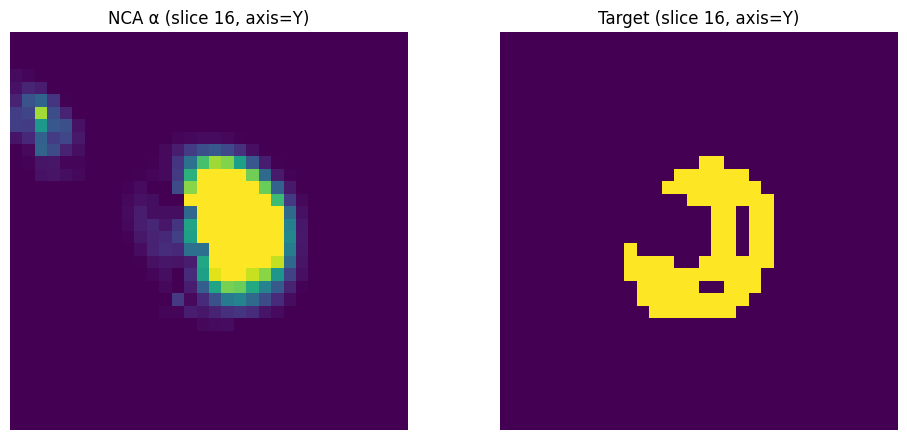

Iter 00800, Loss=0.105686, Mean Alpha=0.0197


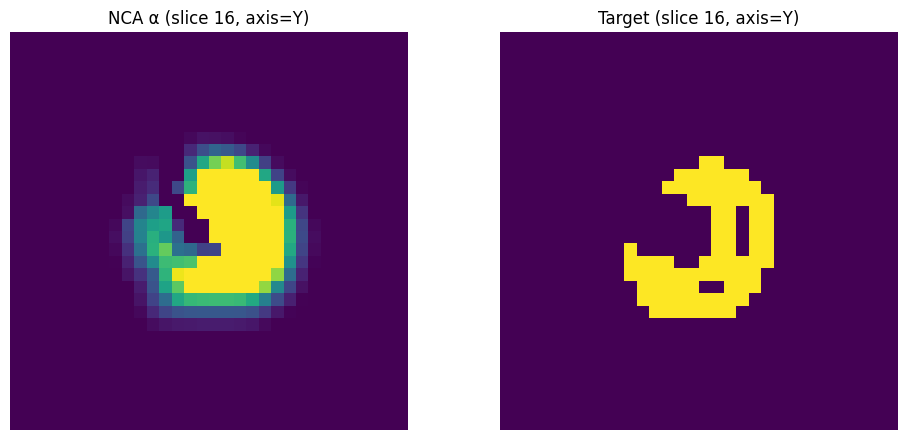

Iter 01000, Loss=0.105681, Mean Alpha=0.0208


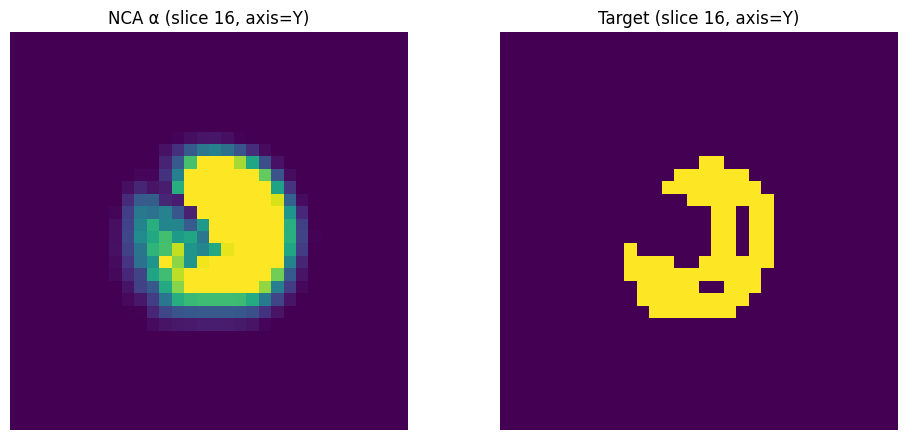

Iter 01200, Loss=0.112687, Mean Alpha=0.0227


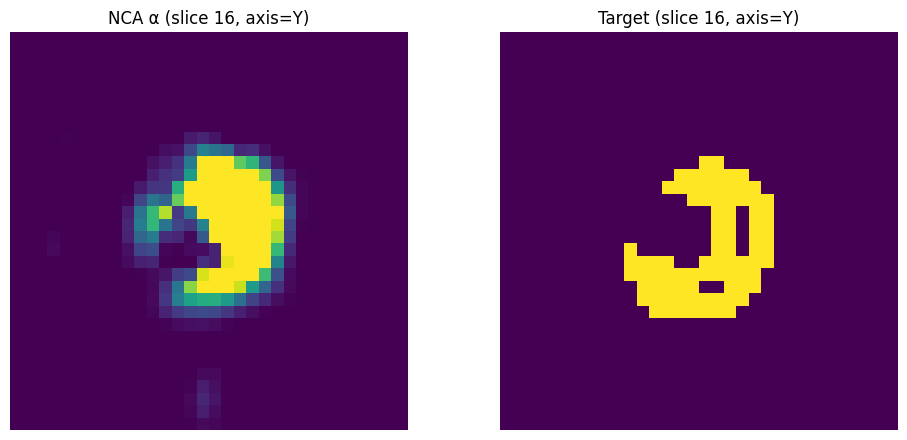

Iter 01400, Loss=0.105448, Mean Alpha=0.0162


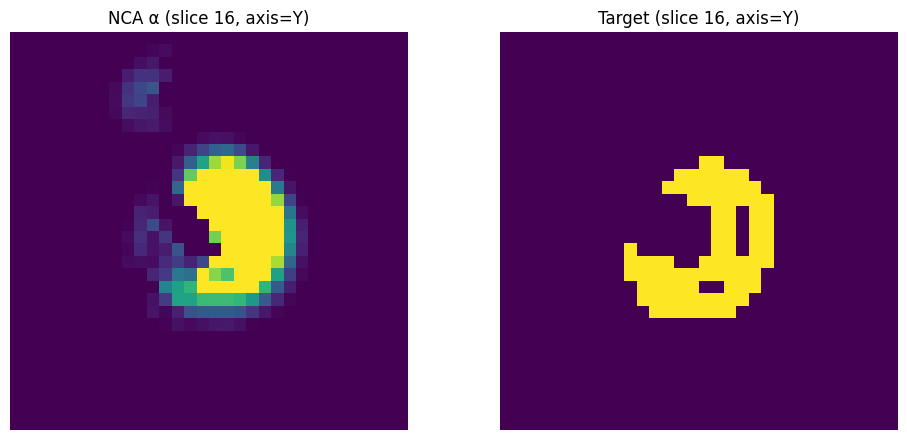

Iter 01600, Loss=0.098734, Mean Alpha=0.0215


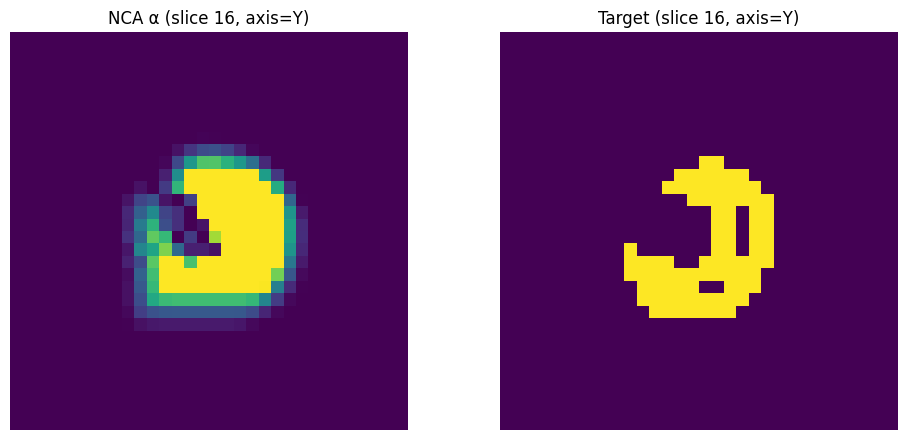

Iter 01800, Loss=0.101460, Mean Alpha=0.0172


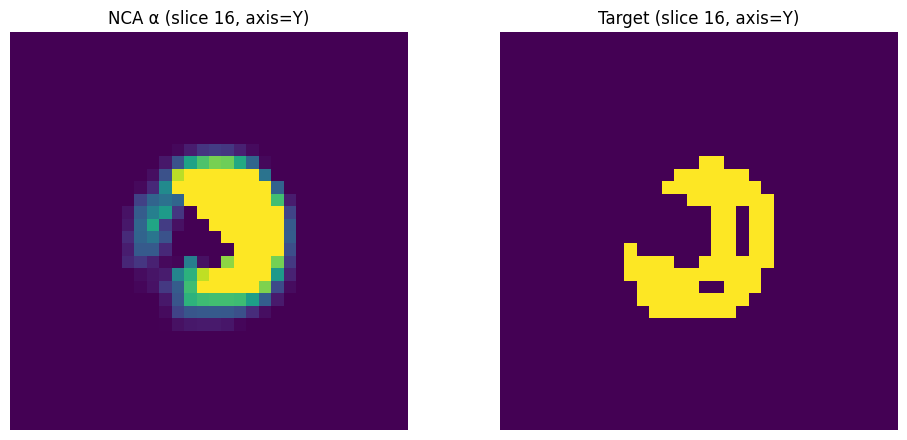

Iter 02000, Loss=0.099276, Mean Alpha=0.0196


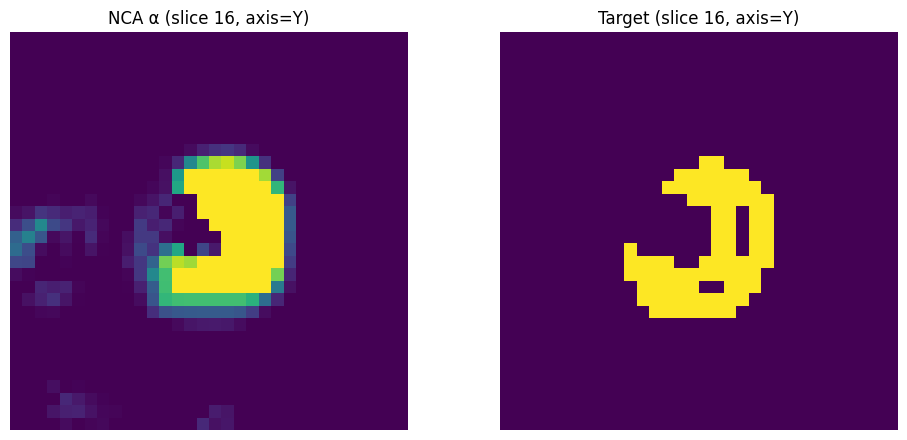

training took 66.77634167671204 s


In [5]:
print("\nstarting multi-step training")
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
losses = []
iters = 2000
n_steps = 8
log_interval = 200

start = time.time()
for it in range(1, iters+1):
    state = model.seed_center(batch_size=1, device=device)
    state += 0.02 * torch.randn_like(state)
    optim.zero_grad()
    loss = 0.0
    for step in range(n_steps):
        state = model(state, steps=1)
        alpha = state[:, -1:, ...]
        loss += F.mse_loss(alpha, target)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optim.step()
    losses.append(loss.item())
    
    if it % log_interval == 0 or it==1:
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
        viz.show_comparison(state, target, axis=1, idx=16)
    if loss.item() < 0.095:
        print("Best result")
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
        viz.show_comparison(state, target, axis=1, idx=16)
        break

print("training took", time.time() - start, "s")

In [6]:
with torch.no_grad():
    state = model.seed_center(batch_size=1, device=device)
    state += 1e-3 * torch.randn_like(state)
    state = model(state, steps=8)
    alpha = state[:, -1:, ...].cpu().numpy().squeeze()

thresh = 0.2
xs, ys, zs = np.nonzero(alpha > thresh)
print("final alive voxels:", len(xs))

final alive voxels: 1067


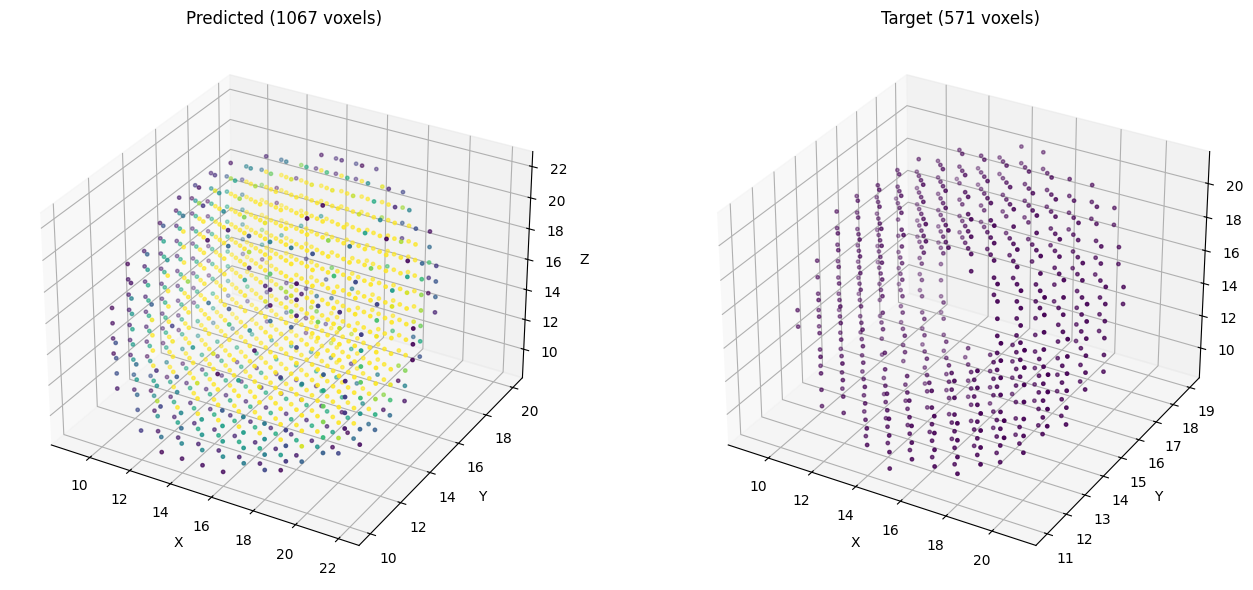

In [7]:
target_np = target.cpu().numpy().squeeze()
xs_t, ys_t, zs_t = np.nonzero(target_np > thresh)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(xs, ys, zs, s=6, c=alpha[alpha > thresh], cmap='viridis')
ax1.set_title(f"Predicted ({len(xs)} voxels)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(xs_t, ys_t, zs_t, s=6, c=target_np[target_np > thresh], cmap='viridis')
ax2.set_title(f"Target ({len(xs_t)} voxels)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.tight_layout()
plt.show()

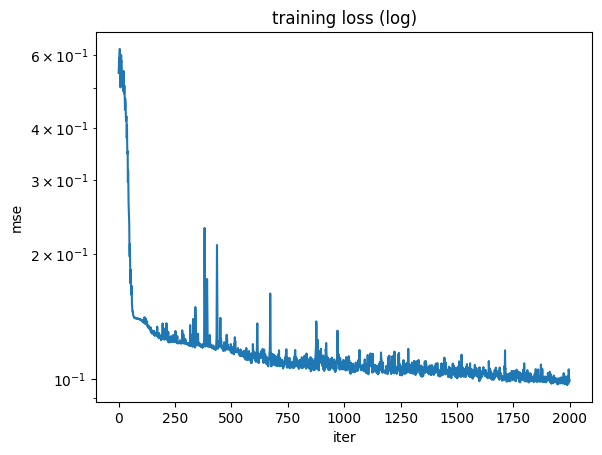

In [8]:
plt.figure()
plt.plot(losses)
plt.yscale("log")
plt.title("training loss (log)")
plt.xlabel("iter")
plt.ylabel("mse")
plt.show()